In [57]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install plotly

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [59]:
from google.colab import files
print("Please upload your CSV files:")
uploaded = files.upload()

# Now read them
orders_df = pd.read_csv("List of Orders.csv")
details_df = pd.read_csv("Order Details.csv")

print("✅ Files loaded!")

Please upload your CSV files:


Saving List of Orders.csv to List of Orders (3).csv
Saving Order Details.csv to Order Details (3).csv
✅ Files loaded!


In [60]:
orders_df.head()

,Order ID,Order Date,CustomerName,State,City
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad
1,B-25602,01-04-2018,Pearl,Maharashtra,Pune
2,B-25603,03-04-2018,Jahan,Madhya Pradesh,Bhopal
3,B-25604,03-04-2018,Divsha,Rajasthan,Jaipur
4,B-25605,05-04-2018,Kasheen,West Bengal,Kolkata


In [61]:
orders_df.tail()

,Order ID,Order Date,CustomerName,State,City
555,NaN,NaN,NaN,NaN,NaN
556,NaN,NaN,NaN,NaN,NaN
557,NaN,NaN,NaN,NaN,NaN
558,NaN,NaN,NaN,NaN,NaN
559,NaN,NaN,NaN,NaN,NaN


In [62]:
details_df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,1275.0,-1148.0,7,Furniture,Bookcases
1,B-25601,66.0,-12.0,5,Clothing,Stole
2,B-25601,8.0,-2.0,3,Clothing,Hankerchief
3,B-25601,80.0,-56.0,4,Electronics,Electronic Games
4,B-25602,168.0,-111.0,2,Electronics,Phones


In [63]:
details_df.tail()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category
1495,B-26099,835.0,267.0,5,Electronics,Phones
1496,B-26099,2366.0,552.0,5,Clothing,Trousers
1497,B-26100,828.0,230.0,2,Furniture,Chairs
1498,B-26100,34.0,10.0,2,Clothing,T-shirt
1499,B-26100,72.0,16.0,2,Clothing,Shirt


In [64]:
orders_df.duplicated().sum()
details_df.duplicated().sum()

np.int64(0)

In [65]:
details_df[details_df.duplicated()]

,Order ID,Amount,Profit,Quantity,Category,Sub-Category


In [66]:
orders_df[details_df.duplicated()]

/tmp/ipython-input-1498741500.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  orders_df[details_df.duplicated()]


,Order ID,Order Date,CustomerName,State,City


In [67]:
orders_df=orders_df.drop_duplicates()
details_df=details_df.drop_duplicates()

In [68]:
print("unique cities:\n",orders_df["City"].unique())

unique cities:
 ['Ahmedabad' 'Pune' 'Bhopal' 'Jaipur' 'Kolkata' 'Bangalore' 'Kashmir'
 'Chennai' 'Lucknow' 'Patna' 'Thiruvananthapuram' 'Chandigarh' 'Simla'
 'Gangtok' 'Goa' 'Kohima' 'Hyderabad' 'Mumbai' 'Indore' 'Surat' 'Udaipur'
 'Allahabad' 'Amritsar' 'Delhi' nan]


In [69]:
print("unique category:\n",details_df["Category"].unique())

unique category:
 ['Furniture' 'Clothing' 'Electronics']


In [70]:
print("unique sub-category:\n",details_df["Sub-Category"].unique())

unique sub-category:
 ['Bookcases' 'Stole' 'Hankerchief' 'Electronic Games' 'Phones' 'Saree'
 'Trousers' 'Chairs' 'Kurti' 'T-shirt' 'Shirt' 'Leggings' 'Tables'
 'Printers' 'Accessories' 'Furnishings' 'Skirt']


In [71]:
orders_df['City']=orders_df['City'].replace({'Deli': 'Delhi'})

In [72]:
details_df['Sub-Category'] = details_df['Sub-Category'].replace({'Hankerchief': 'Handkerchief'})

In [73]:
details_df['Category']=details_df['Category'].replace({
    'Furniure': 'Furniture',
    'Clotthing': 'Clothing'
})

In [74]:
# First, fill NaN values with empty string or a placeholder
orders_df['City'] = orders_df['City'].fillna('').astype(str)
orders_df['State'] = orders_df['State'].fillna('').astype(str)
details_df['Category'] = details_df['Category'].fillna('').astype(str)
details_df['Sub-Category'] = details_df['Sub-Category'].fillna('').astype(str)

# Now apply string operations
orders_df['State'] = orders_df['State'].str.title().str.strip()
orders_df['City'] = orders_df['City'].str.title().str.strip()
details_df['Category'] = details_df['Category'].str.title().str.strip()
details_df['Sub-Category'] = details_df['Sub-Category'].str.title().str.strip()

In [75]:
orders_df=orders_df.dropna()
details_df=details_df.dropna()

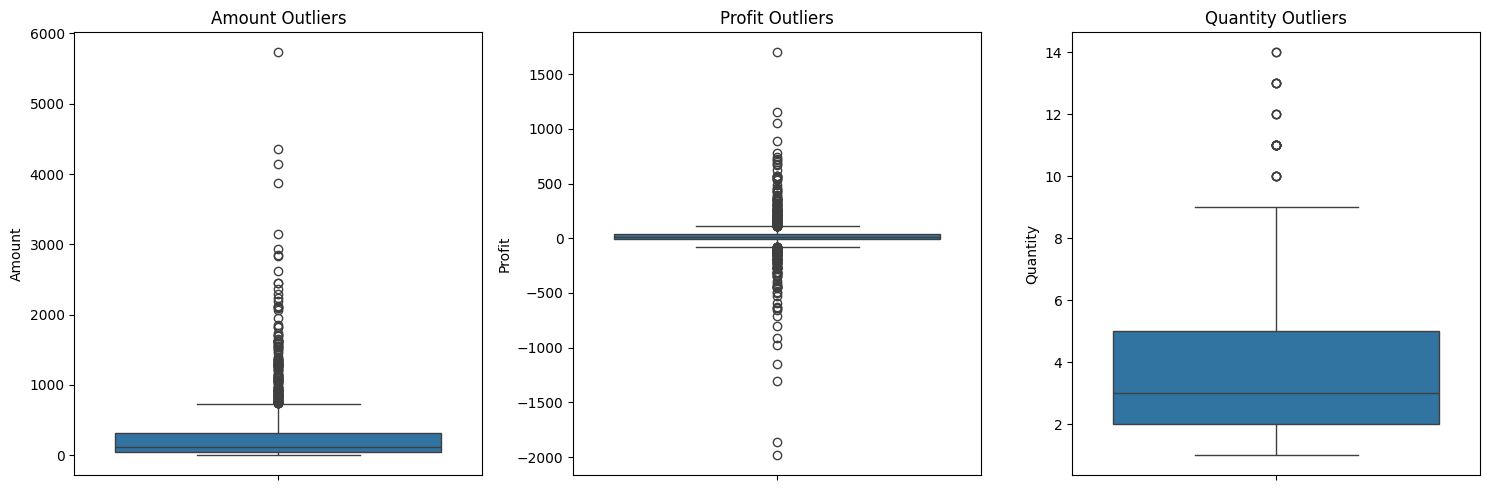

In [76]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=details_df['Amount'])
plt.title('Amount Outliers')

plt.subplot(1, 3, 2)
sns.boxplot(y=details_df['Profit'])
plt.title('Profit Outliers')

plt.subplot(1, 3, 3)
sns.boxplot(y=details_df['Quantity'])
plt.title('Quantity Outliers')

plt.tight_layout()
plt.show()